In [13]:
import os
from ultralytics import YOLO
import shutil
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    if num_gpus > 1:
        DEVICE = ",".join(str(i) for i in range(num_gpus))   # e.g. "0,1,2,3"
    else:
        DEVICE = "0"
    print(f"CUDA available — {num_gpus} GPU(s) detected. Using device: {DEVICE}")
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    DEVICE = "cpu"
    print("No CUDA GPU found — falling back to CPU")

CUDA available — 1 GPU(s) detected. Using device: 0
  GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
def train_vehicle_detector(yaml_file_path, base_model, total_epochs, image_resolution, DEVICE):
    model = YOLO(base_model)
    model.train(
        data=yaml_file_path,
        epochs=total_epochs,
        imgsz=image_resolution,
        batch = 32,
        workers=8,
        device = DEVICE,
        project='outputs',
        name='yolo_training_run',
        exist_ok=True # Overwrites the directory if you re-run it
    )
    optimal_weights_path = os.path.join('outputs', 'yolo_training_run', 'weights', 'best.pt')
    print(f"Optimal weights: {optimal_weights_path}\n")
    return optimal_weights_path

def evaluate_held_out_test_set(weights_file_path, yaml_file_path):
    model = YOLO(weights_file_path)
    metrics = model.val(data=yaml_file_path, split='test')
    map_50 = metrics.box.map50
    map_50_95 = metrics.box.map
    print(f"mAP@0.5IoU:        {map_50:.4f}")
    print(f"mAP@[0.5:0.95]IoU: {map_50_95:.4f}\n")

def execute_visual_inference(weights_file_path, input_directory, output_project_dir, output_run_name):
    model = YOLO(weights_file_path)
    model.predict(
        source=input_directory,
        conf=0.25, # Minimum confidence threshold to render a box
        save=True,
        project=output_project_dir,
        name=output_run_name,
        exist_ok=True
    )

In [ ]:
PATH_TO_CAMPUS_IMAGES = os.path.join('data', 'campus_images')

In [10]:
final_weights_path = 'runs/detect/outputs/yolo_training_run/weights/best.pt'

In [16]:
execute_visual_inference(
        weights_file_path=final_weights_path,
        input_directory=PATH_TO_CAMPUS_IMAGES,
        output_project_dir='assignment_outputs',
        output_run_name='campus_domain_shift_visuals'
    )


image 1/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409135149.jpg: 480x640 (no detections), 12.4ms
image 2/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409135459.jpg: 480x640 (no detections), 11.2ms
image 3/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409135921.jpg: 480x640 (no detections), 8.9ms
image 4/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409140009.jpg: 480x640 1 car, 11.8ms
image 5/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409140049.jpg: 480x640 1 car, 8.1ms
image 6/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409140109.jpg: 480x640 1 car, 11.5ms
image 7/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data\campus_images\IMG20260409140209.jpg: 480x640 1 car, 8.3ms
image 8/12 e:\IISC\Coursework\Sem 2\AIP\Assignments\Assignment 4\data

In [ ]:
image_dir = 'runs/detect/assignment_outputs/campus_domain_shift_visuals'

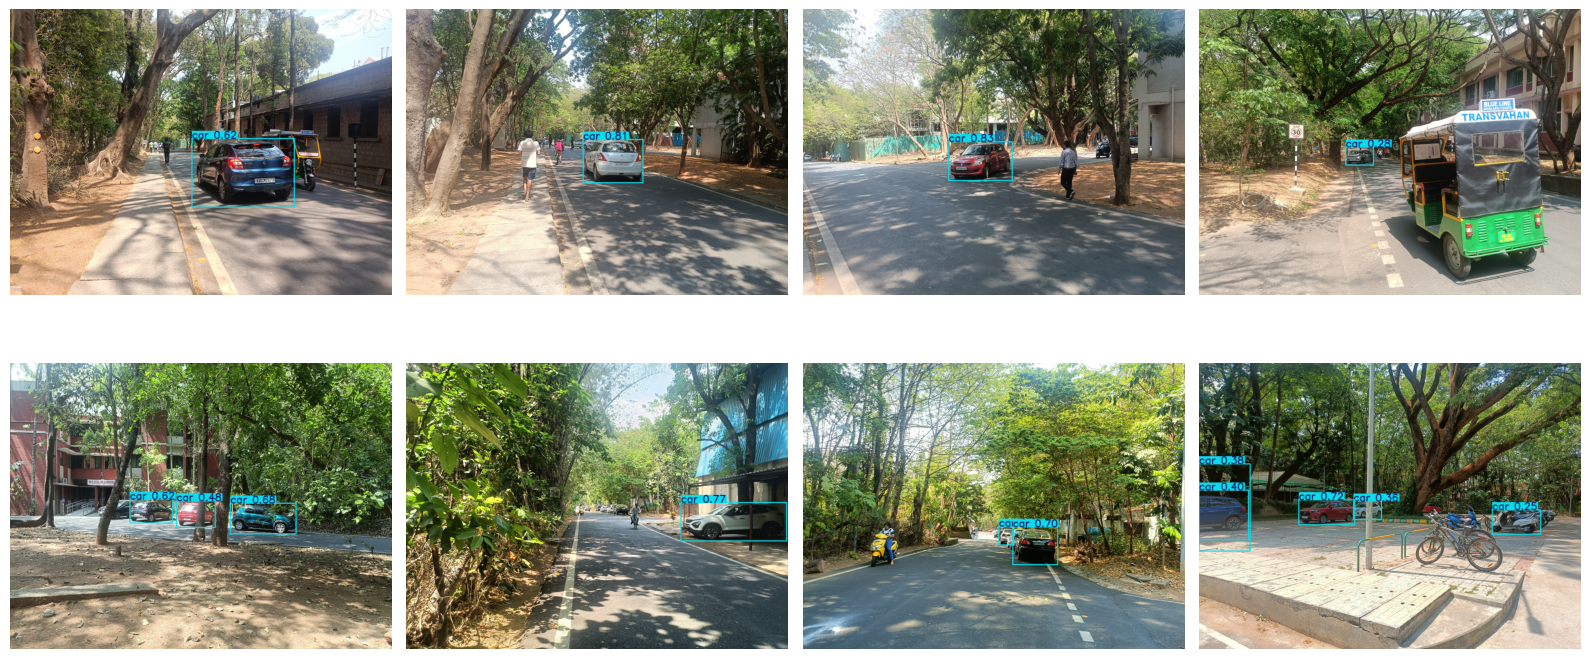

In [18]:
images_to_display = [f for f in os.listdir(image_dir)]
images_to_display = images_to_display[:8]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, img_name in enumerate(images_to_display):
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()